<a href="https://colab.research.google.com/github/R-Nihanth/MLA0401-Deep-Learning-Lab-programs/blob/main/exp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

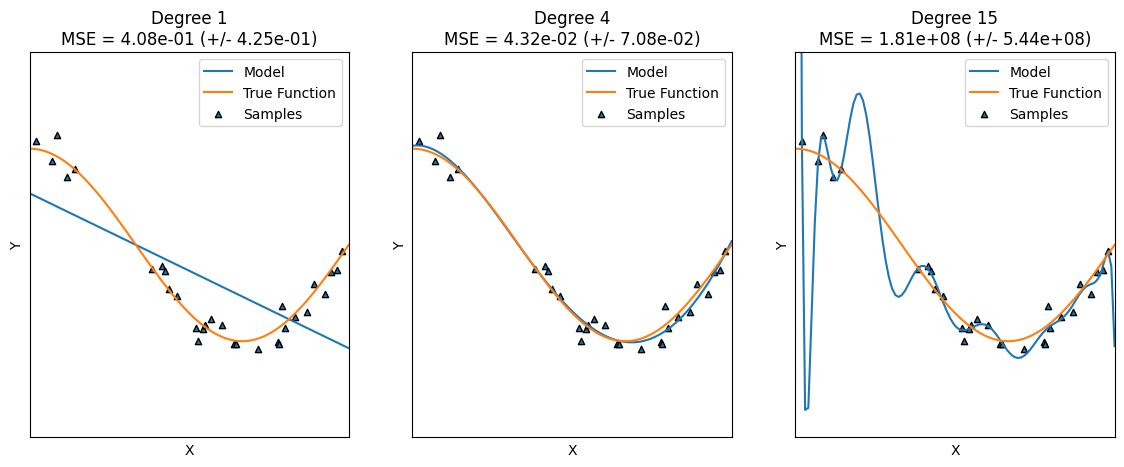

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# True function
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

# Generate sample data
n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # Polynomial regression model
    polynomial_features = PolynomialFeatures(
        degree=degrees[i],
        include_bias=False
    )

    linear_regression = LinearRegression()

    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])

    # Train model
    pipeline.fit(X[:, np.newaxis], y)

    # Cross validation
    scores = cross_val_score(
        pipeline,
        X[:, np.newaxis],
        y,
        scoring="neg_mean_squared_error",
        cv=10
    )

    # Test data
    X_test = np.linspace(0, 1, 100)

    # Plot results
    plt.plot(
        X_test,
        pipeline.predict(X_test[:, np.newaxis]),
        label="Model"
    )

    plt.plot(
        X_test,
        true_fun(X_test),
        label="True Function"
    )

    plt.scatter(
        X,
        y,
        edgecolor="black",
        s=20,
        marker="^",
        label="Samples"
    )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")

    plt.title(
        "Degree {}\nMSE = {:.2e} (+/- {:.2e})".format(
            degrees[i],
            -scores.mean(),
            scores.std()
        )
    )

plt.show()